
# LSTM — Task 2 Incident Classification
## Final aligned protocol

Three-class task:

- `NORMAL`
- `ACCIDENT`
- `OTHER_DISRUPTION`

This notebook follows the aligned Task 2 benchmark protocol:

- same canonical dataset;
- same frozen grouped-random and spatial-holdout manifests;
- same 7-hour window: `t-3 ... t+3`;
- same primary traffic representation:
  1. `log1p(flow)`;
  2. pre-event-normalized relative change;
- three seeds: `42, 52, 62`;
- model selection by validation Macro-F1;
- final reporting as mean ± standard deviation across seeds.

The LSTM consumes the 2 × 7 traffic sequence directly.
Early stopping monitors validation Macro-F1 and restores the best weights.


In [1]:

# Run only if TensorFlow is not installed:
# !pip install -U tensorflow

from pathlib import Path
import json
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

SEEDS = [42, 52, 62]
CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]
CLASS_TO_INT = {label: i for i, label in enumerate(CLASS_ORDER)}
INT_TO_CLASS = {i: label for label, i in CLASS_TO_INT.items()}

DATA_DIR = Path(".")

CANONICAL_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/spatial_split_manifest_revised.csv")

OUTPUT_DIR = DATA_DIR / "lstm_final_aligned_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [CANONICAL_PATH, GROUPED_MANIFEST_PATH, SPATIAL_MANIFEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing file: {p.resolve()}\n"
            "Place this notebook in the same folder as the three revised CSV files "
            "or update DATA_DIR."
        )

print("TensorFlow version:", tf.__version__)
print("Output directory:", OUTPUT_DIR.resolve())


TensorFlow version: 2.19.0
Output directory: /Users/andishahifahmuthahharah/Downloads/lstm_final_aligned_outputs


## 1. Load and validate the frozen data

In [2]:

canonical = pd.read_csv(CANONICAL_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

assert canonical["event_sample_id"].is_unique
assert grouped_manifest["event_sample_id"].is_unique
assert spatial_manifest["event_sample_id"].is_unique

assert set(canonical["event_sample_id"]) == set(grouped_manifest["event_sample_id"])
assert set(canonical["event_sample_id"]) == set(spatial_manifest["event_sample_id"])
assert set(canonical["target_class"].unique()) == set(CLASS_ORDER)

print("Canonical shape:", canonical.shape)
print("Grouped manifest shape:", grouped_manifest.shape)
print("Spatial manifest shape:", spatial_manifest.shape)

display(
    canonical["target_class"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_frame("count")
)

print("Integrity checks passed.")


Canonical shape: (5265, 16)
Grouped manifest shape: (5265, 5)
Spatial manifest shape: (5265, 5)


,count
target_class,
NORMAL,3581
ACCIDENT,505
OTHER_DISRUPTION,1179


Integrity checks passed.


## 2. Build aligned 2 × 7 sequence

In [3]:

FLOW_COLS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

def merge_split(canonical_df, manifest):
    manifest_small = manifest[["event_sample_id", "target_class", "split"]].copy()

    merged = canonical_df.merge(
        manifest_small,
        on="event_sample_id",
        how="inner",
        suffixes=("", "_manifest"),
        validate="one_to_one",
    )

    assert len(merged) == len(canonical_df)
    assert (merged["target_class"] == merged["target_class_manifest"]).all()

    return merged.drop(columns="target_class_manifest")

def encode_target(y):
    encoded = y.map(CLASS_TO_INT)
    if encoded.isna().any():
        raise ValueError("Unknown target class found.")
    return encoded.astype(int).to_numpy()

def decode_target(y_int):
    return np.array([INT_TO_CLASS[int(v)] for v in y_int])

def build_aligned_sequence(df):
    missing = [c for c in FLOW_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing flow columns: {missing}")

    flow = df[FLOW_COLS].astype(float).to_numpy()

    if not np.isfinite(flow).all():
        raise ValueError("Flow matrix contains NaN or infinite values.")
    if (flow < 0).any():
        raise ValueError("Negative flow values found.")

    # Channel 1: log1p(flow)
    log_flow = np.log1p(flow)

    # Channel 2: pre-event-normalized relative change
    baseline = np.median(flow[:, :3], axis=1, keepdims=True)
    rel_change = (flow - baseline) / (baseline + 1.0)
    rel_change = np.clip(rel_change, -5.0, 5.0)

    # Shape: (N, 7, 2)
    X = np.stack([log_flow, rel_change], axis=-1).astype(np.float32)

    return X

def metric_row(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, labels=CLASS_ORDER, average="weighted", zero_division=0
        ),
    }


## 3. LSTM configurations

In [4]:

MODEL_CONFIGS = [
    {
        "lstm_units": 32,
        "dense_units": 16,
        "dropout": 0.20,
        "recurrent_dropout": 0.10,
        "learning_rate": 1e-3,
        "l2_strength": 1e-4,
    },
    {
        "lstm_units": 64,
        "dense_units": 32,
        "dropout": 0.30,
        "recurrent_dropout": 0.10,
        "learning_rate": 1e-3,
        "l2_strength": 1e-4,
    },
    {
        "lstm_units": 32,
        "dense_units": 16,
        "dropout": 0.40,
        "recurrent_dropout": 0.20,
        "learning_rate": 5e-4,
        "l2_strength": 1e-3,
    },
]

MAX_EPOCHS = 35
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 6
WEIGHT_DECAY = 1e-4

print("Model configurations:", len(MODEL_CONFIGS))


Model configurations: 3


In [5]:

class ValidationMacroF1(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        prob = self.model.predict(self.X_val, verbose=0)
        pred = np.argmax(prob, axis=1)
        score = f1_score(
            self.y_val,
            pred,
            average="macro",
            zero_division=0,
        )
        logs["val_macro_f1"] = score

def build_lstm_model(input_shape, config):
    regularizer = tf.keras.regularizers.l2(config["l2_strength"])

    inputs = tf.keras.Input(shape=input_shape, name="traffic_sequence")

    x = tf.keras.layers.LSTM(
        config["lstm_units"],
        dropout=config["dropout"],
        recurrent_dropout=config["recurrent_dropout"],
        kernel_regularizer=regularizer,
        recurrent_regularizer=regularizer,
        name="lstm",
    )(inputs)

    x = tf.keras.layers.Dense(
        config["dense_units"],
        activation="relu",
        kernel_regularizer=regularizer,
        name="dense_hidden",
    )(x)

    x = tf.keras.layers.Dropout(
        config["dropout"],
        name="dropout",
    )(x)

    outputs = tf.keras.layers.Dense(
        len(CLASS_ORDER),
        activation="softmax",
        name="class_output",
    )(x)

    model = tf.keras.Model(inputs, outputs, name="aligned_lstm")

    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=config["learning_rate"],
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


## 4. Run one seed

In [6]:

def run_one_seed(split_name, manifest, seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.backend.clear_session()

    data = merge_split(canonical, manifest)
    X_raw = build_aligned_sequence(data)
    y_label = data["target_class"].astype(str)
    y = encode_target(y_label)

    masks = {
        part: data["split"].eq(part).to_numpy()
        for part in ["train", "validation", "test"]
    }

    X_train_raw = X_raw[masks["train"]]
    X_val_raw = X_raw[masks["validation"]]
    X_test_raw = X_raw[masks["test"]]

    y_train = y[masks["train"]]
    y_val = y[masks["validation"]]
    y_test = y[masks["test"]]

    y_train_label = y_label.loc[masks["train"]]
    y_val_label = y_label.loc[masks["validation"]]
    y_test_label = y_label.loc[masks["test"]]

    # Scale each channel using training data only
    scaler = StandardScaler()
    scaler.fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))

    def scale_3d(arr):
        shape = arr.shape
        return scaler.transform(
            arr.reshape(-1, shape[-1])
        ).reshape(shape).astype(np.float32)

    X_train = scale_3d(X_train_raw)
    X_val = scale_3d(X_val_raw)
    X_test = scale_3d(X_test_raw)

    class_weights_values = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(CLASS_ORDER)),
        y=y_train,
    )
    class_weight = {
        i: float(w) for i, w in enumerate(class_weights_values)
    }

    search_rows = []
    models = []
    histories = []

    for i, config in enumerate(MODEL_CONFIGS, start=1):
        tf.keras.backend.clear_session()
        tf.random.set_seed(seed + i)

        model = build_lstm_model(
            input_shape=X_train.shape[1:],
            config=config,
        )

        macro_cb = ValidationMacroF1(X_val, y_val)

        callbacks = [
            macro_cb,
            tf.keras.callbacks.EarlyStopping(
                monitor="val_macro_f1",
                mode="max",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=True,
                verbose=0,
            ),
            tf.keras.callbacks.TerminateOnNaN(),
        ]

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            class_weight=class_weight,
            callbacks=callbacks,
            verbose=0,
            shuffle=True,
        )

        val_prob = model.predict(X_val, verbose=0)
        val_pred_int = np.argmax(val_prob, axis=1)
        val_pred_label = decode_target(val_pred_int)

        val_macro_f1 = f1_score(
            y_val_label,
            val_pred_label,
            average="macro",
            zero_division=0,
        )

        hist_macro = history.history.get("val_macro_f1", [])
        best_epoch = (
            int(np.argmax(hist_macro) + 1)
            if len(hist_macro) > 0
            else len(history.history["loss"])
        )

        row = {
            **config,
            "epochs_trained": len(history.history["loss"]),
            "best_epoch": best_epoch,
            **metric_row(y_val_label, val_pred_label),
        }

        search_rows.append(row)
        models.append(model)
        histories.append(history.history)

        print(
            f"{split_name} | seed {seed} | config {i}/{len(MODEL_CONFIGS)} | "
            f"epochs={row['epochs_trained']} | "
            f"best_epoch={best_epoch} | "
            f"val_macro_f1={val_macro_f1:.4f}"
        )

    search_df = pd.DataFrame(search_rows)

    ranking = search_df.sort_values(
        ["macro_f1", "balanced_accuracy", "epochs_trained"],
        ascending=[False, False, True],
    )

    best_idx = ranking.index[0]
    best_model = models[best_idx]
    best_history = histories[best_idx]
    best_config = MODEL_CONFIGS[best_idx]

    partition_rows = []
    prediction_frames = []

    for part, X_part, y_part_label in [
        ("train", X_train, y_train_label),
        ("validation", X_val, y_val_label),
        ("test", X_test, y_test_label),
    ]:
        prob = best_model.predict(X_part, verbose=0)
        pred_int = np.argmax(prob, axis=1)
        pred_label = decode_target(pred_int)

        partition_rows.append({
            "split_scheme": split_name,
            "seed": seed,
            "partition": part,
            "best_epoch": int(search_df.loc[best_idx, "best_epoch"]),
            **metric_row(y_part_label, pred_label),
        })

        frame = pd.DataFrame({
            "event_sample_id": data.loc[masks[part], "event_sample_id"].to_numpy(),
            "split_scheme": split_name,
            "seed": seed,
            "partition": part,
            "y_true": y_part_label.to_numpy(),
            "y_pred": pred_label,
        })

        for class_idx, class_name in enumerate(CLASS_ORDER):
            frame[f"prob_{class_name}"] = prob[:, class_idx]

        prediction_frames.append(frame)

    metrics_df = pd.DataFrame(partition_rows)
    predictions_df = pd.concat(prediction_frames, ignore_index=True)

    test_pred = predictions_df.loc[
        predictions_df["partition"].eq("test"), "y_pred"
    ].to_numpy()

    report_df = pd.DataFrame(
        classification_report(
            y_test_label,
            test_pred,
            labels=CLASS_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).T

    return {
        "model": best_model,
        "best_config": best_config,
        "search": search_df,
        "metrics": metrics_df,
        "predictions": predictions_df,
        "report": report_df,
        "history": best_history,
        "scaler": scaler,
    }


## 5. Run all 3 seeds for both split schemes

In [7]:

SPLITS = [
    ("Grouped-random", grouped_manifest),
    ("Spatial holdout", spatial_manifest),
]

all_metrics = []
all_predictions = []
all_reports = []
all_best_configs = []
all_histories = {}

for split_name, manifest in SPLITS:
    for seed in SEEDS:
        print(f"\nRunning {split_name} | seed {seed}")

        out = run_one_seed(
            split_name=split_name,
            manifest=manifest,
            seed=seed,
        )

        all_metrics.append(out["metrics"])
        all_predictions.append(out["predictions"])

        report_tmp = out["report"].reset_index().rename(columns={"index": "class"})
        report_tmp["split_scheme"] = split_name
        report_tmp["seed"] = seed
        all_reports.append(report_tmp)

        best_row = out["search"].sort_values(
            ["macro_f1", "balanced_accuracy", "epochs_trained"],
            ascending=[False, False, True],
        ).iloc[0].to_dict()

        all_best_configs.append({
            "split_scheme": split_name,
            "seed": seed,
            **best_row,
        })

        safe_split = split_name.lower().replace("-", "_").replace(" ", "_")

        out["search"].to_csv(
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_configuration_search.csv",
            index=False,
        )

        out["model"].save(
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_lstm.keras"
        )

        np.savez(
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_scaler.npz",
            mean=out["scaler"].mean_,
            scale=out["scaler"].scale_,
        )

        hist_df = pd.DataFrame(out["history"])
        hist_df["epoch"] = np.arange(1, len(hist_df) + 1)
        hist_df.to_csv(
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_training_history.csv",
            index=False,
        )
        all_histories[(split_name, seed)] = hist_df

df_all_metrics = pd.concat(all_metrics, ignore_index=True)
df_all_predictions = pd.concat(all_predictions, ignore_index=True)
df_all_reports = pd.concat(all_reports, ignore_index=True)
df_best_configs = pd.DataFrame(all_best_configs)

df_all_metrics.to_csv(
    OUTPUT_DIR / "lstm_all_metrics_per_seed.csv",
    index=False,
)
df_all_predictions.to_csv(
    OUTPUT_DIR / "lstm_all_predictions.csv",
    index=False,
)
df_all_reports.to_csv(
    OUTPUT_DIR / "lstm_all_classification_reports.csv",
    index=False,
)
df_best_configs.to_csv(
    OUTPUT_DIR / "lstm_best_configs_per_seed.csv",
    index=False,
)

display(df_best_configs)



Running Grouped-random | seed 42
Grouped-random | seed 42 | config 1/3 | epochs=19 | best_epoch=13 | val_macro_f1=0.2844
Grouped-random | seed 42 | config 2/3 | epochs=7 | best_epoch=1 | val_macro_f1=0.3005
Grouped-random | seed 42 | config 3/3 | epochs=7 | best_epoch=1 | val_macro_f1=0.3052

Running Grouped-random | seed 52
Grouped-random | seed 52 | config 1/3 | epochs=9 | best_epoch=3 | val_macro_f1=0.2967
Grouped-random | seed 52 | config 2/3 | epochs=22 | best_epoch=16 | val_macro_f1=0.3111
Grouped-random | seed 52 | config 3/3 | epochs=11 | best_epoch=5 | val_macro_f1=0.3272

Running Grouped-random | seed 62
Grouped-random | seed 62 | config 1/3 | epochs=13 | best_epoch=7 | val_macro_f1=0.2725
Grouped-random | seed 62 | config 2/3 | epochs=17 | best_epoch=11 | val_macro_f1=0.3243
Grouped-random | seed 62 | config 3/3 | epochs=8 | best_epoch=2 | val_macro_f1=0.3099

Running Spatial holdout | seed 42
Spatial holdout | seed 42 | config 1/3 | epochs=7 | best_epoch=1 | val_macro_f1=0

,split_scheme,seed,lstm_units,dense_units,dropout,recurrent_dropout,learning_rate,l2_strength,epochs_trained,best_epoch,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Grouped-random,42,32.0,16.0,0.4,0.2,0.0005,0.0010,7.0,1.0,0.377551,0.329420,0.329765,0.329420,0.305187,0.418976
1,Grouped-random,52,32.0,16.0,0.4,0.2,0.0005,0.0010,11.0,5.0,0.461735,0.349331,0.365476,0.349331,0.327224,0.486615
2,Grouped-random,62,64.0,32.0,0.3,0.1,0.0010,0.0001,17.0,11.0,0.390306,0.356122,0.351464,0.356122,0.324283,0.430673
3,Spatial holdout,42,32.0,16.0,0.4,0.2,0.0005,0.0010,12.0,6.0,0.368486,0.371966,0.364062,0.371966,0.320766,0.408083
4,Spatial holdout,52,32.0,16.0,0.2,0.1,0.0010,0.0001,7.0,1.0,0.483871,0.365767,0.360871,0.365767,0.342460,0.500539
5,Spatial holdout,62,32.0,16.0,0.4,0.2,0.0005,0.0010,9.0,3.0,0.509926,0.349012,0.346711,0.349012,0.345498,0.519927


## 6. Final mean ± SD results

In [8]:

test_metrics = df_all_metrics[
    df_all_metrics["partition"].eq("test")
].copy()

summary = (
    test_metrics
    .groupby("split_scheme")
    .agg({
        "accuracy": ["mean", "std"],
        "balanced_accuracy": ["mean", "std"],
        "macro_precision": ["mean", "std"],
        "macro_recall": ["mean", "std"],
        "macro_f1": ["mean", "std"],
        "weighted_f1": ["mean", "std"],
    })
)

summary.columns = [
    "_".join(col).strip("_")
    for col in summary.columns.to_flat_index()
]

summary = summary.reset_index()

summary.to_csv(
    OUTPUT_DIR / "lstm_final_test_summary_mean_sd.csv",
    index=False,
)

print("Final LSTM test results (mean ± SD across seeds 42, 52, 62):")
display(summary)


Final LSTM test results (mean ± SD across seeds 42, 52, 62):


,split_scheme,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,Grouped-random,0.419179,0.047011,0.351910,0.018850,0.350145,0.010508,0.351910,0.018850,0.324638,0.013351,0.453876,0.034512
1,Spatial holdout,0.389771,0.062971,0.364171,0.012452,0.355474,0.019001,0.364171,0.012452,0.311862,0.026252,0.404534,0.068964


## 7. Per-class mean ± SD

In [9]:

per_class = df_all_reports[
    df_all_reports["class"].isin(CLASS_ORDER)
].copy()

per_class_summary = (
    per_class
    .groupby(["split_scheme", "class"])
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1-score": ["mean", "std"],
        "support": ["mean"],
    })
)

per_class_summary.columns = [
    "_".join(col).strip("_")
    for col in per_class_summary.columns.to_flat_index()
]

per_class_summary = per_class_summary.reset_index()

per_class_summary.to_csv(
    OUTPUT_DIR / "lstm_per_class_summary_mean_sd.csv",
    index=False,
)

display(per_class_summary)


,split_scheme,class,precision_mean,precision_std,recall_mean,recall_std,f1-score_mean,f1-score_std,support_mean
0,Grouped-random,ACCIDENT,0.098145,0.025300,0.265766,0.076841,0.142755,0.036168,74.0
1,Grouped-random,NORMAL,0.684111,0.007713,0.475046,0.104252,0.556338,0.068024,541.0
2,Grouped-random,OTHER_DISRUPTION,0.268179,0.022420,0.314917,0.139441,0.274822,0.063809,181.0
3,Spatial holdout,ACCIDENT,0.139194,0.035060,0.135135,0.082199,0.125100,0.028162,74.0
4,Spatial holdout,NORMAL,0.682350,0.017098,0.358576,0.114453,0.463273,0.106297,515.0
5,Spatial holdout,OTHER_DISRUPTION,0.244878,0.006498,0.598802,0.063371,0.347213,0.016442,167.0


## 8. Aggregate confusion matrices

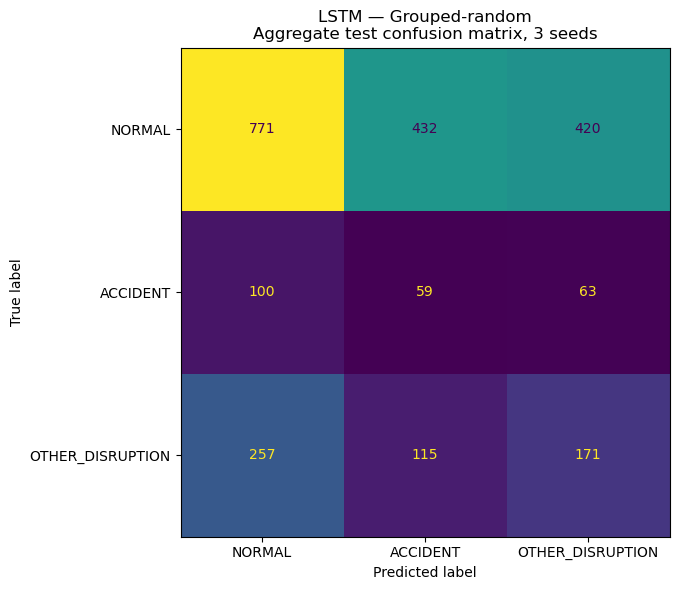

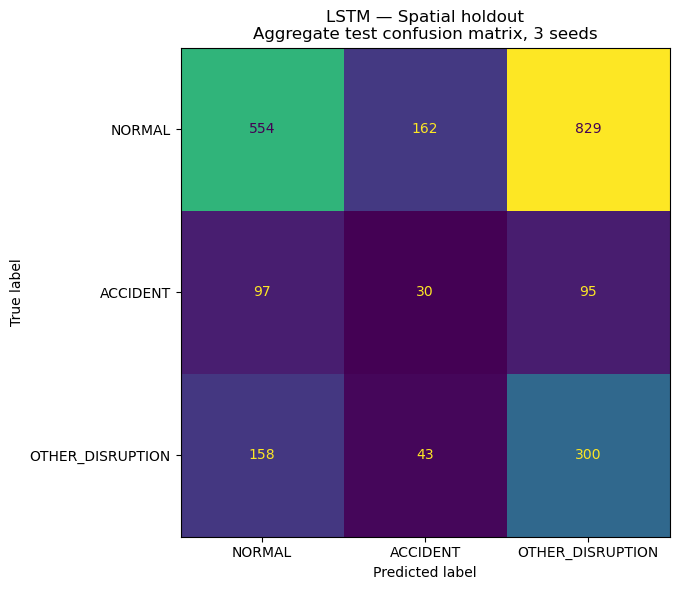

In [10]:

for split_name, _ in SPLITS:
    subset = df_all_predictions[
        (df_all_predictions["split_scheme"] == split_name)
        & (df_all_predictions["partition"] == "test")
    ]

    cm_sum = np.zeros((len(CLASS_ORDER), len(CLASS_ORDER)), dtype=int)

    for seed in SEEDS:
        seed_df = subset[subset["seed"] == seed]
        cm_sum += confusion_matrix(
            seed_df["y_true"],
            seed_df["y_pred"],
            labels=CLASS_ORDER,
        )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_sum,
        display_labels=CLASS_ORDER,
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"LSTM — {split_name}\nAggregate test confusion matrix, 3 seeds")
    fig.tight_layout()
    plt.show()


## 9. Training curves for seed 42

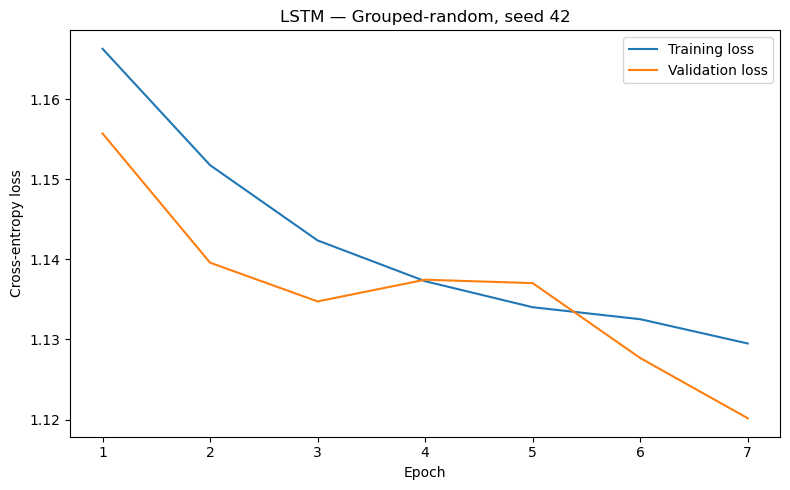

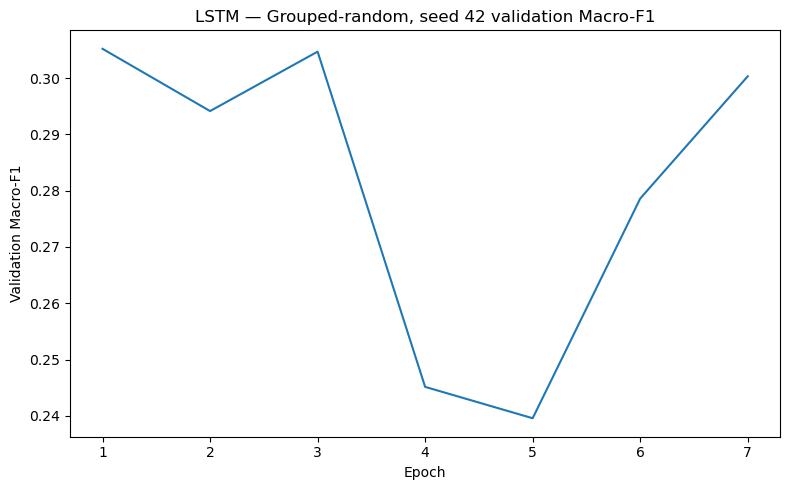

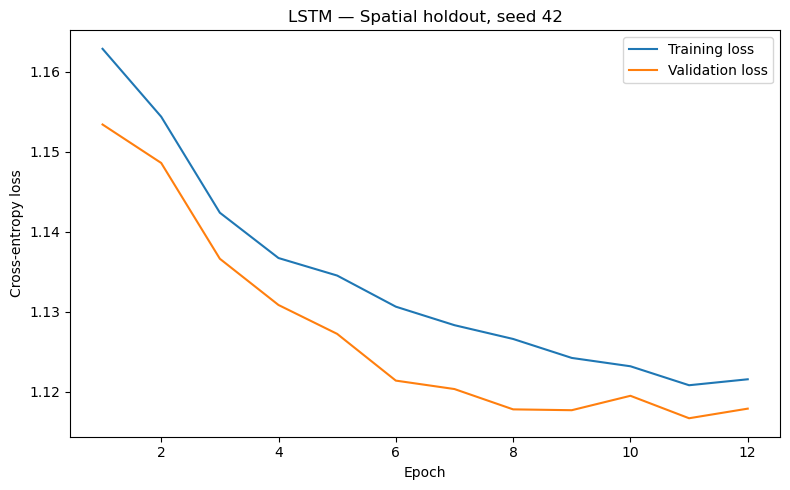

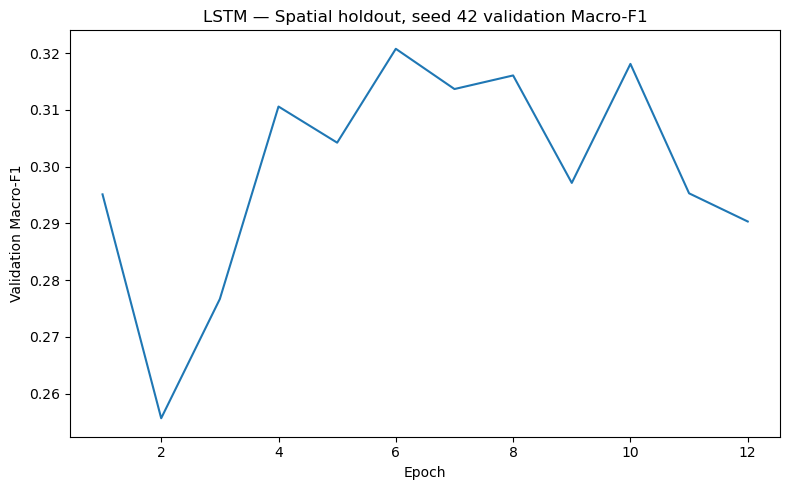

In [11]:

for split_name in ["Grouped-random", "Spatial holdout"]:
    hist_df = all_histories[(split_name, 42)]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["loss"], label="Training loss")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], label="Validation loss")
    ax.set_title(f"LSTM — {split_name}, seed 42")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend()
    fig.tight_layout()
    plt.show()

    if "val_macro_f1" in hist_df.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(hist_df["epoch"], hist_df["val_macro_f1"])
        ax.set_title(f"LSTM — {split_name}, seed 42 validation Macro-F1")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation Macro-F1")
        fig.tight_layout()
        plt.show()



## Reporting guidance

Use:

- `lstm_final_test_summary_mean_sd.csv`
- `lstm_per_class_summary_mean_sd.csv`

for the final benchmark table and class-level interpretation.

Primary metric:
- test Macro-F1 mean ± SD across seeds 42, 52, and 62.

Aligned neural settings:
- 7 hourly timesteps;
- 2 input channels;
- maximum 35 epochs;
- batch size 64;
- AdamW;
- weight decay 1e-4;
- early stopping patience 6;
- validation Macro-F1 for model selection;
- frozen test split used only for final evaluation.
